In [1]:
import numpy as np
import matplotlib.pyplot as plt
from few.waveform import GenerateEMRIWaveform

from Triangle.Constants import * 
from Triangle.GW import * 
from Triangle.FFTTools import *
from Triangle.Noise import *
from Triangle.Orbit import *
from Triangle.TDI import *
from Triangle.Cosmology import *

PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


no cupy 


/Users/taijidatacenter/miniconda3/envs/few_env/lib/python3.9/site-packages/pycbc/waveform/plugin.py:99: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## EMRI waveform wrapper 

In [2]:
class EMRI_Injection:
    def __init__(self):
        
        # keyword arguments for inspiral generator (EMRIInspiral)
        inspiral_kwargs = {
            "DENSE_STEPPING": 0,  # we want a sparsely sampled trajectory
            "buffer_length": int(1e3),  # all of the trajectories will be well under len = 1000
        }

        # keyword arguments for summation generator (InterpolatedModeSum)
        sum_kwargs = {
            "pad_output": True,
            "odd_len": False, 
        }

        self.waveform_generator = GenerateEMRIWaveform(
            "Pn5AAKWaveform",
            inspiral_kwargs=inspiral_kwargs,
            sum_kwargs=sum_kwargs,
        )
        
    def __call__(self, params, times): 
        """  
        Parameters: 
            params: a dictionary containing source parameters: 
                m1, m2, a, p0, e0, x0 (i.e. Y parameter for AAK), # 6 intrinsic 
                dist, latitude (i.e. pi/2 - qS), longitude (i.e. phiS), qK, phiK, # 5 extrinsic 
                Phi_phi0, Phi_theta0, Phi_r0 # 3 phases 
            times: a numpy array of times 
        Returns: 
            times, hp+ihc 
        """
        
        # data settings 
        dt = times[1] - times[0] # sampling time cadance in s 
        Tobs = len(times) * dt / YEAR # total observation time in year 
        data_kwargs = {
            "dt": dt, # time cadance in                      
            "T": Tobs,         
        }
        
        # source parameter settings     
        parameters = [
            params["m1"], params["m2"], params["a"], params["p0"], params["e0"], params["x0"], # 6 intrinsic 
            params["dist"], PI/2. - params["latitude"], params["longitude"], params["qK"], params["phiK"], # 5 extrinsic 
            params["Phi_phi0"], params["Phi_theta0"], params["Phi_r0"] # 3 phases 
            ]
        
        # generate waveform hp - ihc
        waveform_td = self.waveform_generator(*parameters, **data_kwargs) 
        
        # convert to hp + ihc, which will be used by the TDI response generator 
        return times.copy(), np.conjugate(waveform_td)

## Data settings 

In [3]:
Tobs = 0.5 * YEAR 
dt = 25.
tcb_times = np.arange(int(Tobs/dt))*dt 

## Source parameters 

In [4]:
mu = np.random.uniform(10, 100)
lg10q = np.random.uniform(4.5, 5.5)

emri_parameters = dict(
    m1 = mu * np.power(10., lg10q),  # central object mass in solar masses
    m2 = mu,  # secondary object mass in solar masses
    a = np.random.uniform(0.1, 0.6),  # dimensionless spin parameter of the central object 
    p0 = np.random.uniform(11., 15.),  # initial semi-latus rectum
    e0 = np.random.uniform(0.3, 0.6),  # eccentricity
    x0 = np.cos(np.random.uniform(0., np.deg2rad(70.))), # initial cosine inclination，Y=cosι=L/√(L²+Q) for AAK  
    Phi_phi0 = np.random.uniform(0, TWOPI), # initial phi phase 
    Phi_theta0 = np.random.uniform(0, TWOPI), # initial theta phase 
    Phi_r0 = np.random.uniform(0, TWOPI),  # initial r phase 
    qK = np.random.uniform(0, PI),  # polar spin angle
    phiK = np.random.uniform(0, TWOPI),  # azimuthal spin angle
    latitude = PI/2 - np.random.uniform(0, PI), # Ecliptic latitude, equal to pi/2 - qS 
    longitude = np.random.uniform(0, TWOPI), # Ecliptic longitude, equal to phiS  
    dist = 1.,  # distance in Gpc, fiducial value is 1 and will be adjusted according to SNR (the target SNR should fall in [50, 100])
)

target_SNR = np.random.uniform(50, 100)

emri_parameters

{'m1': 7039714.256408592,
 'm2': 29.979385398076552,
 'a': 0.20335957766971322,
 'p0': 14.674443631751686,
 'e0': 0.4465233566384487,
 'x0': 0.733468088466293,
 'Phi_phi0': 4.81234099049053,
 'Phi_theta0': 3.257316284380882,
 'Phi_r0': 1.8648525506672493,
 'qK': 0.5897436328850378,
 'phiK': 0.5073123535864998,
 'latitude': -0.7490822828584585,
 'longitude': 2.7728276252226935,
 'dist': 1.0}

## Waveform & response model settings 

In [5]:
# initialze waveform wrapper 
emri_waveform_generator = EMRI_Injection()

# set Taiji orbit model 
orbit = Orbit(OrbitDir="../../Triangle-Simulator/OrbitData/TaijiEqualArmOrbit", dt=DAY)

# set Taiji noise model 
PSDfunc = TDIPSDs()

# we test 2 different response models using 2 interpolation methods 
TDI_response_generator_spl5 = FastMichelsonTDIResponse(
    orbit=orbit, 
    tcb_times=tcb_times, 
    use_gpu=False, 
    drop_points=int(1000./dt), 
    interp_method="Spline5",  # accurate but slow 
)

TDI_response_generator_lin = FastMichelsonTDIResponse(
    orbit=orbit, 
    tcb_times=tcb_times, 
    use_gpu=False, 
    drop_points=int(1000./dt), 
    # interp_method="Akima", 
    interp_method="linear", 
)

## Generate waveform (before projection to TDI)

In [6]:
emri_time, emri_wf = emri_waveform_generator(
    params=emri_parameters, 
    times=tcb_times, 
)
emri_time.shape, emri_wf.shape 

((631162,), (631162,))

(0.1, 0.11)

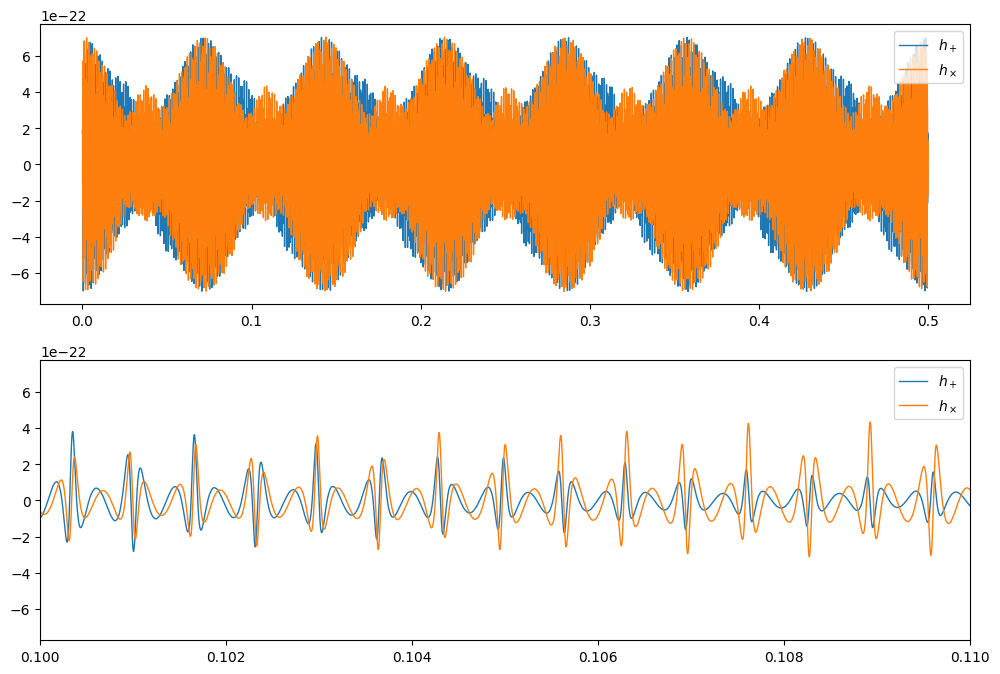

In [7]:
plt.figure(figsize=(12, 8))
plt.subplot(211)
plt.plot(emri_time/YEAR, np.real(emri_wf), linewidth=1, label=r"$h_+$")
plt.plot(emri_time/YEAR, np.imag(emri_wf), linewidth=1, label=r'$h_\times$')
plt.legend(loc="upper right")

plt.subplot(212)
plt.plot(emri_time/YEAR, np.real(emri_wf), linewidth=1, label=r"$h_+$")
plt.plot(emri_time/YEAR, np.imag(emri_wf), linewidth=1, label=r'$h_\times$')
plt.legend(loc="upper right")
plt.xlim(0.1, 0.11)

## Generate TDI responses 

In [8]:
tdi_spl5 = TDI_response_generator_spl5(
    parameters=emri_parameters, 
    waveform_generator=emri_waveform_generator, 
    optimal_combination=True, 
)

In [9]:
tdi_lin = TDI_response_generator_lin(
    parameters=emri_parameters, 
    waveform_generator=emri_waveform_generator, 
    optimal_combination=True, 
)

(0.1, 0.11)

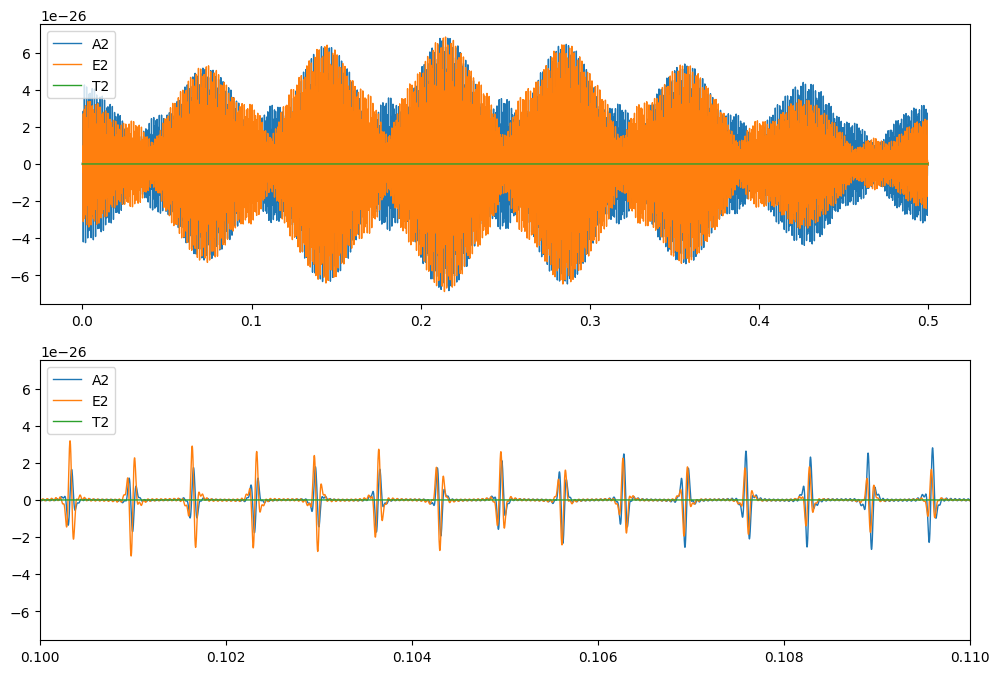

In [10]:
channel_names = ["A2", "E2", "T2"] 
plt.figure(figsize=(12,8))
plt.subplot(211)
for i in range(3): 
    plt.plot(tcb_times/YEAR, tdi_spl5[i], linewidth=1, label=channel_names[i])
plt.legend(loc="upper left")
plt.subplot(212)
for i in range(3): 
    plt.plot(tcb_times/YEAR, tdi_spl5[i], linewidth=1, label=channel_names[i])
plt.legend(loc="upper left")
plt.xlim(0.1, 0.11)

## Compare different interpolation methods 

total SNR: 0.38231137795874204
residual SNR (rescaled to SNR=50): 0.5973052589065858
total SNR: 0.37753894570053675
residual SNR (rescaled to SNR=50): 0.6160544610981457


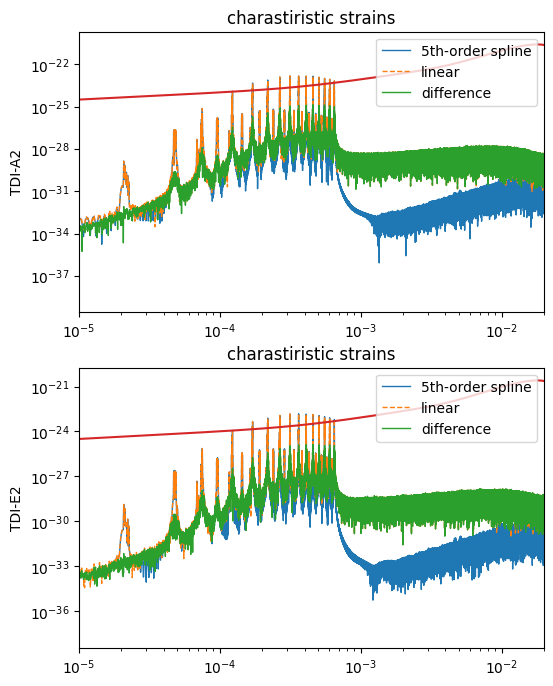

In [11]:
FFT_kwargs = dict(
    fsample=1./dt, 
    window_type="tukey", 
    window_args_dict=dict(alpha=0.1)
)


plt.figure(figsize=(6,8))
for i in range(2): 
    plt.subplot(211+i)
    ff, xf_spl5 = FFT_window(
        tdi_spl5[i], 
        **FFT_kwargs, 
    )
    _, xf_lin = FFT_window(
        tdi_lin[i], 
        **FFT_kwargs, 
    )
    _, xf_diff = FFT_window(
        tdi_spl5[i]-tdi_lin[i], 
        **FFT_kwargs, 
    )
    plt.loglog(ff, np.abs(xf_spl5)*2.*ff, linewidth=1, label="5th-order spline")
    plt.loglog(ff, np.abs(xf_lin)*2.*ff, linewidth=1, linestyle="--", label="linear")
    plt.loglog(ff, np.abs(xf_diff)*2.*ff, linewidth=1, label="difference")
    plt.loglog(ff, np.sqrt(PSDfunc.PSD_A2(ff)*ff))
    plt.xlim(1e-5, 0.02)
    # plt.ylim(1e-25,)
    plt.ylabel("TDI-"+channel_names[i])
    plt.legend(loc="upper right")
    plt.title("charastiristic strains")
    tot_SNR = np.sqrt(np.sum(np.abs(xf_spl5[ff<0.024])**2/PSDfunc.PSD_A2(ff[ff<0.024]))*4./Tobs)
    print("total SNR:", tot_SNR)
    print("residual SNR (rescaled to SNR=50):", np.sqrt(np.sum(np.abs(xf_diff[ff<0.024])**2/PSDfunc.PSD_A2(ff[ff<0.024]))*4./Tobs)*50/tot_SNR)

In [12]:
def residual_SNR_of_random_EMRI():
    mu = np.random.uniform(10, 100)
    lg10q = np.random.uniform(4.5, 5.5)

    emri_parameters = dict(
        m1 = mu * np.power(10., lg10q),  # central object mass in solar masses
        m2 = mu,  # secondary object mass in solar masses
        a = np.random.uniform(0.1, 0.6),  # dimensionless spin parameter of the central object 
        p0 = np.random.uniform(11., 15.),  # initial semi-latus rectum
        e0 = np.random.uniform(0.3, 0.6),  # eccentricity
        x0 = np.cos(np.random.uniform(0., np.deg2rad(70.))), # initial cosine inclination，Y=cosι=L/√(L²+Q) for AAK  
        Phi_phi0 = np.random.uniform(0, TWOPI), # initial phi phase 
        Phi_theta0 = np.random.uniform(0, TWOPI), # initial theta phase 
        Phi_r0 = np.random.uniform(0, TWOPI),  # initial r phase 
        qK = np.random.uniform(0, PI),  # polar spin angle
        phiK = np.random.uniform(0, TWOPI),  # azimuthal spin angle
        latitude = PI/2 - np.random.uniform(0, PI), # Ecliptic latitude, equal to pi/2 - qS 
        longitude = np.random.uniform(0, TWOPI), # Ecliptic longitude, equal to phiS  
        dist = 1.,  # distance in Gpc, fiducial value is 1 and will be adjusted according to SNR (the target SNR should fall in [50, 100])
    )

    tdi_spl5 = TDI_response_generator_spl5(
        parameters=emri_parameters, 
        waveform_generator=emri_waveform_generator, 
        optimal_combination=True, 
    )

    tdi_lin = TDI_response_generator_lin(
        parameters=emri_parameters, 
        waveform_generator=emri_waveform_generator, 
        optimal_combination=True, 
    )

    FFT_kwargs = dict(
        fsample=1./dt, 
        window_type="tukey", 
        window_args_dict=dict(alpha=0.1)
    )
    tot_SNR_AE = 0. 
    res_SNR_AE = 0. 
    for i in range(2):
        ff, xf_spl5 = FFT_window(
            tdi_spl5[i], 
            **FFT_kwargs, 
        )
        _, xf_diff = FFT_window(
            tdi_spl5[i]-tdi_lin[i], 
            **FFT_kwargs, 
        )
        
        tot_SNR = np.sqrt(np.sum(np.abs(xf_spl5[ff<0.024])**2/PSDfunc.PSD_A2(ff[ff<0.024]))*4./Tobs)
        res_SNR = np.sqrt(np.sum(np.abs(xf_diff[ff<0.024])**2/PSDfunc.PSD_A2(ff[ff<0.024]))*4./Tobs)
        tot_SNR_AE += tot_SNR ** 2 
        res_SNR_AE += res_SNR ** 2 
    tot_SNR_AE = np.sqrt(tot_SNR_AE)
    res_SNR_AE = np.sqrt(res_SNR_AE) * 100. / tot_SNR_AE
    return res_SNR_AE

In [13]:
res_SNRs = [] 
for i in tqdm(range(100)):
    res_SNRs.append(residual_SNR_of_random_EMRI())

100%|██████████| 100/100 [08:51<00:00,  5.31s/it]


Text(0, 0.5, 'Source number')

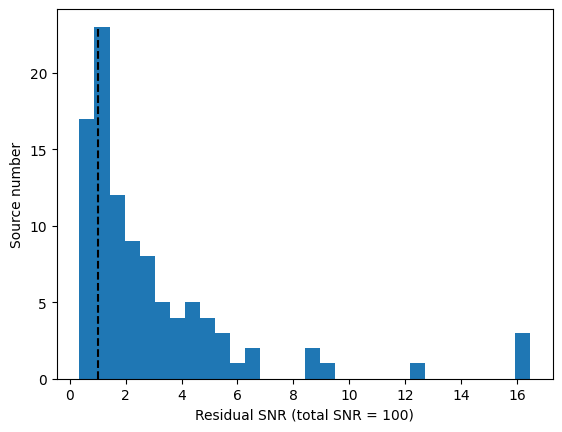

In [ ]:

probs, _, _ = plt.hist(np.array(res_SNRs), bins=25, density=False) 
plt.vlines(1, 0, np.max(probs), color="k", linestyle="--")
plt.xlabel("Residual SNR (total SNR = 100)")
plt.ylabel("Source number")
print("fraction of sources with residual SNR < 1:", len(np.where(np.array(res_SNRs)<1)[0]) / len(res_SNRs))
print("fraction of sources with residual SNR < 5:", len(np.where(np.array(res_SNRs)<5)[0]) / len(res_SNRs))
print("fraction of sources with residual SNR < 10:", len(np.where(np.array(res_SNRs)<10)[0]) / len(res_SNRs))